# Flow Matching

from Outlier video

## Data

In [1]:
import tqdm
import math
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
from ipywidgets import interact, Layout, IntSlider

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(device)

# ------
from dataloader import getDataLoader
from vae import VAE
from train import VAEConfig

cuda
cuda


## Model

Very important training additions: LayerNorm + Residuals in the Blocks

### CFG

Adding conditioning $y$ and dropout layer, using a null $y = \varnothing$ classification.
Then, when we sample, we will use the formula: $\tilde{u}_t(x|y) = (1 - w)u_t^{\text{target}}(x | \varnothing) + wu_t^{\text{target}}(x|y)$.

In [2]:
class Block(nn.Module):
    def __init__(self, channels=512):
        super().__init__()
        self.ln = nn.LayerNorm(channels)
        self.ff = nn.Linear(channels, channels)
        self.act = nn.GELU()

    def forward(self, x):
        return x + self.act(self.ff(self.ln(x)))

class MLP(nn.Module):
    def __init__(self, channels_data=784, layers=5, channels=512, channels_t=512, p_drop = 0.2):
        super().__init__()
        self.channels_t = channels_t
        self.p_drop = p_drop
        
        self.in_projection = nn.Linear(channels_data, channels)
        self.label_embed = nn.Embedding(16, channels) # 10 + 1 = 11 total digit labels. 16 for faster kernals
        self.t_projection = nn.Linear(channels_t, channels)
        
        self.ln = nn.LayerNorm(channels)
        self.blocks = nn.Sequential(*[
            Block(channels) for _ in range(layers)
        ])
        self.out_projection = nn.Linear(channels, channels_data)

    def gen_t_embedding(self, t, w_min = 1.0, w_max=10000.0):
        dimension = self.channels_t
        half_dim = dimension // 2
        
        w = w_min * ((w_max / w_min) ** ((torch.linspace(start=1, end=half_dim, steps=half_dim, device=t.device) - 1) / (half_dim - 1)))
        args = 2 * math.pi * t * w.unsqueeze(0) # 64 x 256
        
        emb = math.sqrt(2.0 / dimension) * torch.cat([torch.cos(args), torch.sin(args)], dim=1) # Batch x t_channels
        if dimension % 2 == 1:  # zero pad
            emb = nn.functional.pad(emb, (0, 1), mode='constant')
        return emb
    
    def dropout_classification(self, y):
        drop = torch.rand(y.shape, device=device) < self.p_drop
        y = y.masked_fill(drop, 10) # 10 is the null classification
        
        return y

    def forward(self, x, t, y):
        x = self.in_projection(x)
        y = self.label_embed(self.dropout_classification(y))
        
        t = self.gen_t_embedding(t)
        t = self.t_projection(t)
        
        x = self.ln(x + t + y)
        x = self.blocks(x)
        x = self.out_projection(x)
        return x

In [3]:
batch_size = 256
train_loader = getDataLoader('test', batch_size=batch_size)

vae = VAE(VAEConfig).to(device=device)
vae.load_state_dict(torch.load("vaemnist_30001.pt", weights_only=True)['model'])
vae.eval()
for child in vae.children():
    for params in child.parameters():
        params.requires_grad = False

model = MLP(layers=4, channels_data=VAEConfig.latent_channels, channels=512).to(device=device)
# self.MLP.load_state_dict(torch.load(ckpt_path, weights_only=True))
optim = torch.optim.AdamW(model.parameters(), lr=3e-4, fused=True)

print(sum(p.numel() for p in model.parameters()), "total parameters")

torch.Size([10000, 784])
1 epoch = 39.0625 batches
1359904 total parameters


## Training

In [36]:
# epsilon = torch.randn((batch_size, VAEConfig().latent_channels), device=device)
overfit_data = next(iter(train_loader))

def overfit(model, data, iters=250):
    z = data[0].to(device)
    y = data[1].to(device)
    
    with torch.no_grad():
        z, _, _ = vae.encode(z)
    for _ in range(iters):
        epsilon = torch.randn_like(z, device=device)
        t = torch.rand(z.size(0), 1, device=device)
        xt = t * z + (1 - t) * epsilon
        loss = ((model(xt, t, y) - (z - epsilon))**2).mean()
        
        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
    print(loss.item())

overfit(model, overfit_data, iters=250)

1.308276653289795


100%|██████████| 39/39 [00:00<00:00, 97.29it/s, loss=1.52]


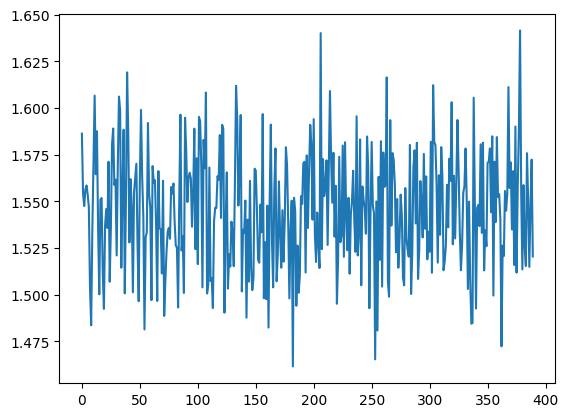

In [32]:
losses = []

model.train().requires_grad_(True)
for epoch in range(10):
    pbar = tqdm.tqdm(train_loader)
    for batch_idx, (images, labels) in enumerate(pbar):
        z = images.to(device)
        y = labels.to(device)
            
        with torch.no_grad():
            z, _, _ = vae.encode(z)        
        epsilon = torch.randn_like(z, device=device)
        
        t = torch.rand(z.size(0), 1, device=device)
        xt = t * z + (1 - t) * epsilon
        loss = ((model(xt, t, y) - (z - epsilon))**2).mean()
        
        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
        
        pbar.set_postfix(loss=loss.item())
        losses.append(loss.item())
        

# torch.save(model.state_dict(), f"mlp_50epoch.pt")
plt.plot(losses)

## Sampling

Euler Numerical Method

Basically, we're following the parameterized vector field $u_{t}^{\text{target}}(x)$.

interactive(children=(IntSlider(value=0, description='batch_idx', max=255), IntSlider(value=0, description='nu…

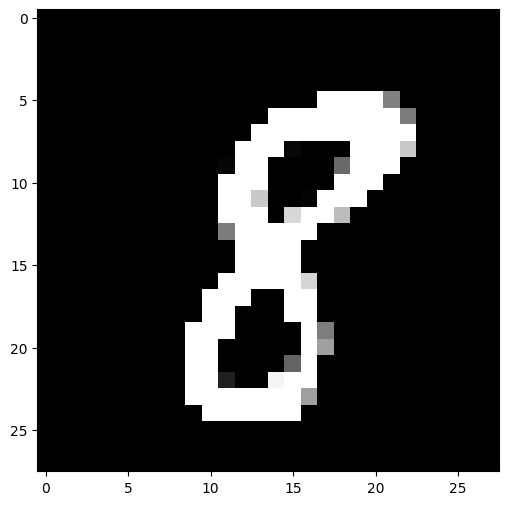

In [ ]:
torch.manual_seed(42)
model.eval()
steps = 100

w = 4.0

@torch.no_grad()
def create_classification(id):
    return torch.full_like(torch.ones(batch_size), fill_value=id, dtype=torch.int32, device=device)

@torch.no_grad()
def sample_image(id):
    outputs = []
    X_0 = epsilon # torch.randn(batch_size, 784, device=device)
    
    null_classification = create_classification(10)
    for _, t in enumerate(torch.linspace(0, 1, steps, device=device), start=1):
        outputs.append(vae.decoder(X_0))
        
        X_0 = X_0 + (1 / steps) * ((1 - w) * model(X_0, t.view(1,1), null_classification) + w * model(X_0, t.view(1,1), create_classification(id))) 
    return outputs # X_0, ..., X_1

@torch.no_grad()
def show_image(batch_idx, number):
    outputs = sample_image(number)
    X_i = outputs[steps - 1][batch_idx].view(28, 28).cpu()
    plt.figure(figsize=(6, 6))
    plt.imshow(X_i.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.show()

interact(show_image, 
        # step= IntSlider(min=0, max=(steps - 1)),
        batch_idx=IntSlider(min=0, max=batch_size - 1),
        number=IntSlider(min=0, max=10),
        layout=Layout(width='75%'))
show_image(batch_idx=2, number=8)


# Interpolation from $p_{\text{init}} \rightarrow p_{\text{data}}$.

Linear interpoloation has some noise redundancy as it only starts turning into noise around $60 \%$ through.

interactive(children=(IntSlider(value=0, description='t', layout=Layout(width='75%')), Output()), _dom_classes…

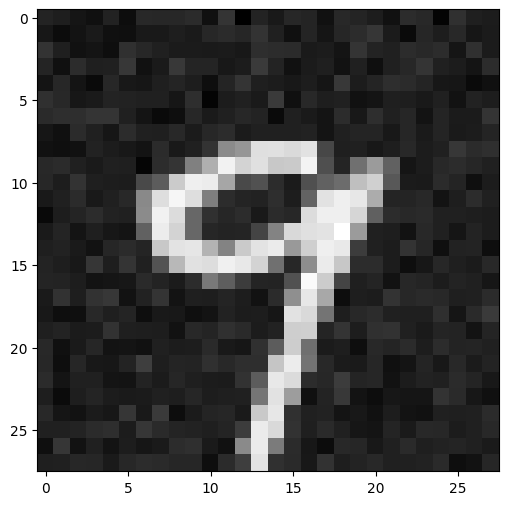

In [39]:
max_steps = 100
z = next(iter(train_loader))[0][0].to(device)
@torch.no_grad()
def show_image_interpolation(t):
    t = torch.tensor(t / max_steps, device=device).unsqueeze(0)
    X_i = t * z + (1 - t) * torch.randn_like(z, device=device)
    X_i = X_i.view(28, 28).cpu()
    
    plt.figure(figsize=(6, 6))
    plt.imshow(X_i.squeeze(), cmap="gray") #, vmin=0, vmax=1)
    plt.show()
            
interact(show_image_interpolation, t=IntSlider(min=0, max=(max_steps), layout=Layout(width='75%')))
show_image_interpolation(max_steps * 0.95)